<a href="https://colab.research.google.com/github/Bader7771/V2-OF-QR-Code-Attendance-System/blob/main/ErroTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing values:
 age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


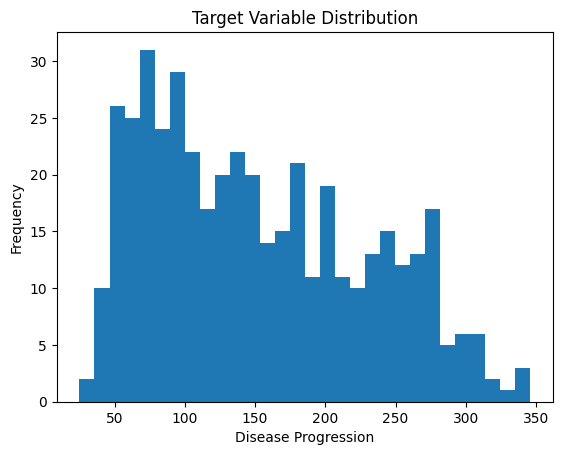

Feature Importance:
   Feature  Importance
2     bmi    0.355469
8      s5    0.230957
3      bp    0.088408
9      s6    0.071329
0     age    0.058642
5      s2    0.057227
4      s1    0.052784
6      s3    0.051339
7      s4    0.024213
1     sex    0.009633
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
Cross-Validation R^2 Scores: [0.50033534 0.20370956 0.44243134 0.5754481  0.32264501]
Mean CV R^2 Score: 0.4089138695712702
Training Mean Squared Error: 1846.7265281055604
Training R^2 Score: 0.6960820334416372
Test Mean Squared Error: 2929.381840559439
Test R^2 Score: 0.4470936319671064


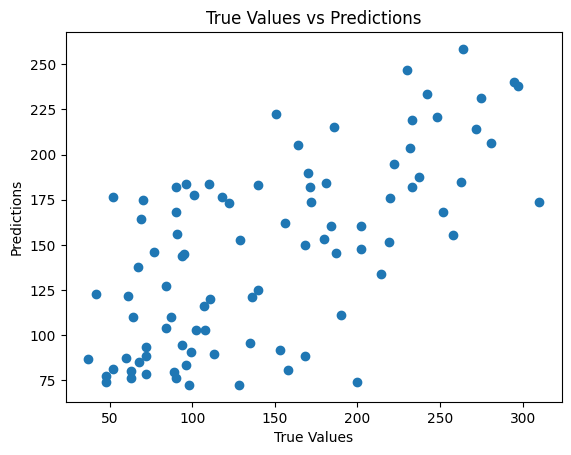

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
diabetes = load_diabetes()

# 2. Convert to DataFrame for easier manipulation
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_df['target'] = diabetes.target

# 3. Check for missing values
print("Missing values:\n", diabetes_df.isnull().sum())

# 4. Visualize the target variable distribution
plt.hist(diabetes.target, bins=30)
plt.xlabel('Disease Progression')
plt.ylabel('Frequency')
plt.title('Target Variable Distribution')
plt.show()

# 5. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(diabetes_df.drop(columns=['target']))

# 6. Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, diabetes.target, test_size=0.2, random_state=42)

# 7. Feature Importance Analysis
rf_temp = RandomForestRegressor(random_state=42)
rf_temp.fit(X_train, y_train)
importances = rf_temp.feature_importances_
feature_names = diabetes.feature_names
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("Feature Importance:\n", feature_importance_df)

# Use top features only (optional)
top_features = feature_importance_df['Feature'][:8].values
X_train_reduced = pd.DataFrame(X_train, columns=feature_names)[top_features].values
X_test_reduced = pd.DataFrame(X_test, columns=feature_names)[top_features].values

# 8. Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_reduced, y_train)

print("Best Parameters:", grid_search.best_params_)

# Use the best model
best_model = grid_search.best_estimator_

# Evaluate the model with Cross-Validation
cv_scores = cross_val_score(best_model, X_train_reduced, y_train, cv=5, scoring='r2')
print("Cross-Validation R^2 Scores:", cv_scores)
print("Mean CV R^2 Score:", np.mean(cv_scores))

# 9. Train the best model on the full training data
best_model.fit(X_train_reduced, y_train)

# 10. Evaluate the model on the training data
y_train_pred = best_model.predict(X_train_reduced)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
print(f"Training Mean Squared Error: {mse_train}")
print(f"Training R^2 Score: {r2_train}")

# 11. Evaluate the model on the test set
y_pred = best_model.predict(X_test_reduced)
mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"Test Mean Squared Error: {mse_test}")
print(f"Test R^2 Score: {r2_test}")

# 12. Visualize the predicted vs actual values
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True Values vs Predictions')
plt.show()
